In [17]:
import nibabel
import pydicom
import numpy as np
from tqdm import tqdm
import glob
import os

In [26]:
import SimpleITK as sitk
import os
import time
from glob import glob


def writeSlices(series_tag_values, new_img, i, out_dir):
    image_slice = new_img[:, :, i]
    writer = sitk.ImageFileWriter()
    writer.KeepOriginalImageUIDOn()

    # Tags shared by the series.
    list(map(lambda tag_value: image_slice.SetMetaData(tag_value[0], tag_value[1]), series_tag_values))

    # Slice specific tags.
    image_slice.SetMetaData("0008|0012", time.strftime("%Y%m%d"))  # Instance Creation Date
    image_slice.SetMetaData("0008|0013", time.strftime("%H%M%S"))  # Instance Creation Time

    # Setting the type to CT preserves the slice location.
    image_slice.SetMetaData("0008|0060", "CT")  # set the type to CT so the thickness is carried over

    # (0020, 0032) image position patient determines the 3D spacing between slices.
    image_slice.SetMetaData("0020|0032", '\\'.join(map(str, new_img.TransformIndexToPhysicalPoint((0, 0, i)))))  # Image Position (Patient)
    image_slice.SetMetaData("0020,0013", str(i))  # Instance Number

    # Write to the output directory and add the extension dcm, to force writing in DICOM format.
    writer.SetFileName(os.path.join(out_dir, str(i).zfill(3) + '.dcm'))
    writer.Execute(image_slice)



def nifti2dicom_1file(in_dir, out_dir):
    """
    This function is to convert only one nifti file into dicom series

    `nifti_dir`: the path to the one nifti file
    `out_dir`: the path to output
    """

    os.makedirs(out_dir, exist_ok=True)

    new_img = sitk.ReadImage(in_dir) 
    modification_time = time.strftime("%H%M%S")
    modification_date = time.strftime("%Y%m%d")

    direction = new_img.GetDirection()
    series_tag_values = [("0008|0031",modification_time), # Series Time
                    ("0008|0021",modification_date), # Series Date
                    ("0008|0008","DERIVED\\SECONDARY"), # Image Type
                    ("0020|000e", "1.2.826.0.1.3680043.2.1125."+modification_date+".1"+modification_time), # Series Instance UID
                    ("0020|0037", '\\'.join(map(str, (direction[0], direction[3], direction[6],# Image Orientation (Patient)
                                                        direction[1],direction[4],direction[7])))),
                    ("0008|103e", "Created-Pycad")] # Series Description

    # Write slices to output directory
    list(map(lambda i: writeSlices(series_tag_values, new_img, i, out_dir), range(new_img.GetDepth())))

def nifti2dicom_mfiles(nifti_dir, out_dir=''):
    """
    This function is to convert multiple nifti files into dicom files

    `nifti_dir`: You enter the global path to all of the nifti files here.
    `out_dir`: Put the path to where you want to save all the dicoms here.

    PS: Each nifti file's folders will be created automatically, so you do not need to create an empty folder for each patient.
    """

    images = glob(nifti_dir + '/*.nii.gz')

    for image in images:
        o_path = out_dir + '/' + os.path.basename(image)[:-7]
        os.makedirs(o_path, exist_ok=True)

        nifti2dicom_1file(image, o_path)

input_dir = "E:\\Documents\\segmented.nii"
output_dir = "E:\\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\anatomicalDataSegment"

nifti2dicom_1file(input_dir,output_dir)

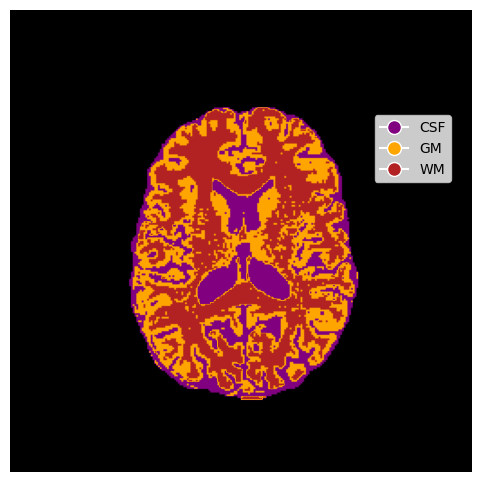

In [66]:
import pydicom
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_dicom(dicom_file_path, colormap):
    # Read the DICOM file
    dicom = pydicom.dcmread(dicom_file_path)

    # Extract the pixel data
    pixel_data = dicom.pixel_array

    # Rotate the pixel data by 180 degrees
    rotated_data = np.rot90(pixel_data, 2)

    # Create a figure and axes
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot the rotated pixel data using the custom colormap
    ax.imshow(rotated_data, cmap=colormap)
    ax.axis('off')

    # Create legend elements
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                       for label, color in zip(labels, colors[1:])]

    # Add legend to the plot
    ax.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.97,0.7))

    # Display the plot
    plt.show()

# Specify the path to your DICOM file
dicom_file_path = "E:\\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\anatomicalDataSegment\\089.dcm"

# Define the values and colors for segmentation colormap
colors = ['black', 'purple', 'orange', 'firebrick']
values = [0, 1/3, 2/3, 1]
labels = ['CSF', 'GM', 'WM']

# Create a custom colormap dictionary
custom_colormap = LinearSegmentedColormap.from_list("mycmap", list(zip(values, colors)))

# Plot the DICOM file (with rotated image) using the custom colormap and legend
plot_dicom(dicom_file_path, custom_colormap)
